In [74]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import contextily as ctx
from pyproj import Transformer

plt.style.use('seaborn-v0_8-paper')
sns.set_palette('colorblind')

BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
DATA_DIR = BASE_DIR / 'data'
PLOTS_DIR = BASE_DIR / 'plots' / 'tesis_data_section'
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Directorio de salida: {PLOTS_DIR}")

Directorio de salida: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section


## 1. Cargar datos del stack multivariado

In [82]:
# Cargar uno de los stacks (usando el full imputed que tiene todas las variables procesadas)
stack_path = DATA_DIR / 'autoencoder_stack' / 'autoencoder_stack_ssp245_full_imputed.nc'

if stack_path.exists():
    ds = xr.open_dataset(stack_path)
    print(f"Dataset cargado: {stack_path.name}")
    print(f"\nDimensiones: {dict(ds.dims)}")
    print(f"\nVariables ({len(ds.data_vars)}):")
    for var in list(ds.data_vars)[:10]:
        print(f"  - {var}")
    if len(ds.data_vars) > 10:
        print(f"  ... y {len(ds.data_vars) - 10} más")
else:
    print(f"No se encontró: {stack_path}")
    print("\nArchivos disponibles en autoencoder_stack:")
    for f in (DATA_DIR / 'autoencoder_stack').glob('*.nc'):
        print(f"  - {f.name}")

Dataset cargado: autoencoder_stack_ssp245_full_imputed.nc

Dimensiones: {'lat': 24, 'lon': 42, 'year': 86}

Variables (20):
  - calliope_cf_mean
  - calliope_cap_electrolyzer_mw
  - calliope_h2_prod_ton
  - climate_tmax_mean
  - climate_tmin_mean
  - climate_prcptot
  - climate_r10mm
  - climate_rx1day
  - climate_rx5day
  - climate_cdd
  ... y 10 más


/tmp/ipykernel_705000/1489006957.py:7: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"\nDimensiones: {dict(ds.dims)}")


## 2. Mapa de la grilla 24×42 sobre Valle de Aconcagua

Comunas en el área: 82
Mapa político con comunas y localidades agregado correctamente
Dibujadas 82 comunas con colores pasteles

Agregando nombres de comunas...
Límites del área de estudio: X=[-8012220, -7784015], Y=[-3938522, -3786304]
Columnas en GeoDataFrame: ['FID', 'region', 'cut', 'region_1', 'ine', 'comuna', 'provincia', 'shape_leng', 'cont', 'shape_le_1', 'shape_area', 'Shape__Area', 'Shape__Length', 'geometry']
Ejemplo primera comuna: {'FID': np.int32(2792), 'region': np.int32(13), 'cut': np.int32(13604), 'region_1': 'XIII', 'ine': np.int32(674), 'comuna': 'PADRE HURTADO', 'provincia': 'TALAGANTE', 'shape_leng': np.float64(49258.181895), 'cont': np.int32(0), 'shape_le_1': np.float64(49258.1532687), 'shape_area': np.float64(80995357.5887), 'Shape__Area': np.float64(116943569.3671875), 'Shape__Length': np.float64(59173.1284566422), 'geometry': <POLYGON ((-7894905.744 -3963117.719, -7894369.718 -3963093.439, -7893876.22...>}
Usando columna de nombres: 'comuna'
Comunas principales

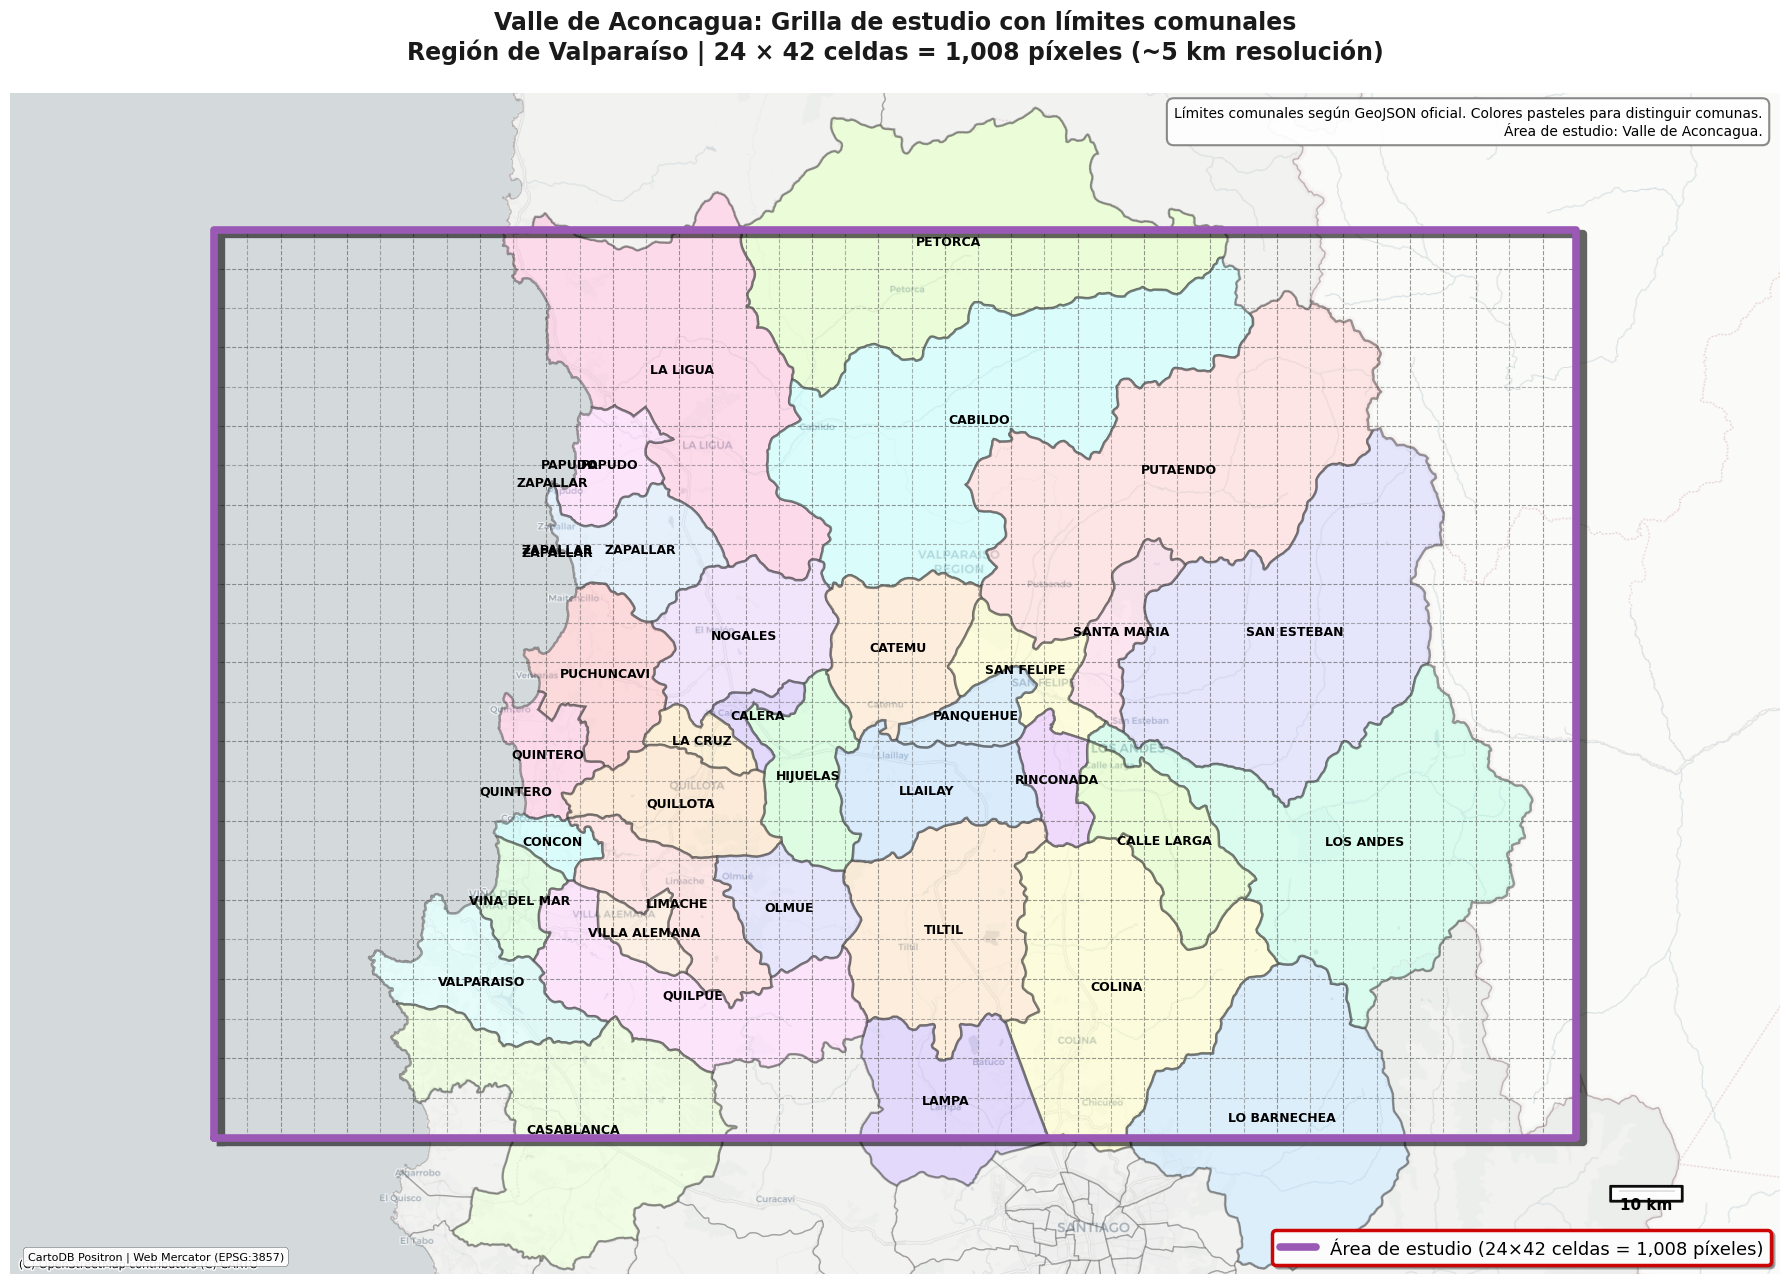


Grilla: 24 × 42 = 1008 píxeles
Rango latitud: [-33.3250, -32.1750]
Rango longitud: [-71.9750, -69.9250]
Resolución aproximada: ~0.0500° (5.55 km)

Coordenadas Web Mercator:
X: [-8012220, -7784015] m
Y: [-3938522, -3786304] m

Comunas en el área: 82


In [76]:
# Extraer coordenadas de la grilla
lats = ds.lat.values
lons = ds.lon.values

# Límites del Valle de Aconcagua
lat_min, lat_max = lats.min(), lats.max()
lon_min, lon_max = lons.min(), lons.max()

# Cargar comunas de Chile desde GeoJSON
comunas_path = DATA_DIR / 'comunas' / 'Comunas_de_Chile.geojson'
comunas_gdf = gpd.read_file(comunas_path)

# Filtrar comunas que intersectan con el área de estudio (con margen)
bbox_margin = 0.2
bbox_filter = (
    (comunas_gdf.geometry.bounds['minx'] < lon_max + bbox_margin) &
    (comunas_gdf.geometry.bounds['maxx'] > lon_min - bbox_margin) &
    (comunas_gdf.geometry.bounds['miny'] < lat_max + bbox_margin) &
    (comunas_gdf.geometry.bounds['maxy'] > lat_min - bbox_margin)
)
comunas_area = comunas_gdf[bbox_filter].copy()

# Reproyectar comunas a Web Mercator (EPSG:3857)
comunas_area = comunas_area.to_crs("EPSG:3857")

print(f"Comunas en el área: {len(comunas_area)}")
if 'NOM_COMUNA' in comunas_area.columns:
    print(f"Comunas: {', '.join(sorted(comunas_area['NOM_COMUNA'].values))}")

# Transformar coordenadas a Web Mercator (EPSG:3857) para contextily
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Transformar esquinas del área
x_min, y_min = transformer.transform(lon_min, lat_min)
x_max, y_max = transformer.transform(lon_max, lat_max)

# Transformar todas las coordenadas de la grilla
lon_grid, lat_grid = np.meshgrid(lons, lats)
x_grid, y_grid = transformer.transform(lon_grid.ravel(), lat_grid.ravel())
x_grid = x_grid.reshape(lon_grid.shape)
y_grid = y_grid.reshape(lat_grid.shape)

# Crear figura sin proyección (trabajamos en coordenadas planas Web Mercator)
fig, ax = plt.subplots(figsize=(18, 16))

# Establecer límites con margen
margin_x = (x_max - x_min) * 0.15
margin_y = (y_max - y_min) * 0.15
ax.set_xlim(x_min - margin_x, x_max + margin_x)
ax.set_ylim(y_min - margin_y, y_max + margin_y)

# Agregar mapa político con nombres (sin imagen satelital)
try:
    ctx.add_basemap(
        ax, 
        crs="EPSG:3857",
        source=ctx.providers.CartoDB.Positron,  # Mapa político limpio con etiquetas
        zoom=10
    )
    print("Mapa político con comunas y localidades agregado correctamente")
except Exception as e:
    print(f"Advertencia: No se pudo cargar mapa político: {e}")
    try:
        # Fallback a OpenStreetMap
        ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.OpenStreetMap.Mapnik)
        print("Mapa OSM agregado como fallback")
    except Exception as e2:
        print(f"Advertencia: No se pudo cargar ningún mapa base: {e2}")

# Generar colores pasteles únicos para cada comuna
n_comunas = len(comunas_area)
# Paleta de colores pasteles suaves
pastel_colors = [
    '#FFB3BA', '#FFDFBA', '#FFFFBA', '#BAFFC9', '#BAE1FF',  # rosado, durazno, amarillo, verde menta, azul cielo
    '#C9B3FF', '#FFB3E6', '#B3FFE6', '#FFE6B3', '#E6B3FF',  # lavanda, rosa, turquesa, beige, violeta
    '#B3D9FF', '#FFD9B3', '#D9FFB3', '#FFB3D9', '#B3FFFF',  # azul claro, naranja claro, verde lima, fucsia claro, cyan
    '#FFCCCC', '#CCFFCC', '#CCCCFF', '#FFCCFF', '#CCFFFF',  # colores más suaves
    '#FFE5CC', '#E5FFCC', '#CCE5FF', '#FFCCE5', '#E5CCFF',  # tonos intermedios
]

# Determinar qué comunas están dentro del área de estudio (sin margen - solo el rectángulo exacto)
# Asignar colores a cada comuna (reciclar si hay más comunas que colores)
comuna_colors = {}
comuna_dentro = {}
for idx, (_, comuna) in enumerate(comunas_area.iterrows()):
    comuna_name = comuna.get('comuna', f'Comuna_{idx}')
    centroid = comuna.geometry.centroid
    cx, cy = centroid.x, centroid.y
    
    # Verificar si está dentro del área de estudio (sin margen adicional)
    dentro = (x_min <= cx <= x_max and y_min <= cy <= y_max)
    comuna_dentro[idx] = dentro
    
    # Asignar color: gris si está fuera, color pastel si está dentro
    if dentro:
        comuna_colors[comuna_name] = pastel_colors[idx % len(pastel_colors)]
    else:
        comuna_colors[comuna_name] = '#DDDDDD'  # Gris claro para comunas fuera del área

# Dibujar las comunas con colores según ubicación
for idx, (_, comuna) in enumerate(comunas_area.iterrows()):
    comuna_name = comuna.get('comuna', f'Comuna_{idx}')
    color = comuna_colors[comuna_name]
    dentro = comuna_dentro[idx]
    
    # Opacidad y grosor de borde según si está dentro o fuera
    alpha = 0.45 if dentro else 0.25
    linewidth = 1.8 if dentro else 1.0
    
    # Dibujar el polígono de la comuna
    if comuna.geometry.geom_type == 'Polygon':
        x, y = comuna.geometry.exterior.xy
        ax.fill(x, y, color=color, alpha=alpha, edgecolor='#333333', linewidth=linewidth, zorder=2)
    elif comuna.geometry.geom_type == 'MultiPolygon':
        for poly in comuna.geometry.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, color=color, alpha=alpha, edgecolor='#333333', linewidth=linewidth, zorder=2)

print(f"Dibujadas {n_comunas} comunas con colores pasteles")

# Dibujar grilla de estudio con color neutro que combine con pasteles
for i in range(len(lats)):
    alpha = 0.6 if i % 2 == 0 else 0.45
    ax.plot([x_min, x_max], [y_grid[i, 0], y_grid[i, 0]], 
            color='#555555', linewidth=0.8, alpha=alpha, zorder=3, linestyle='--')

for i in range(len(lons)):
    alpha = 0.6 if i % 2 == 0 else 0.45
    ax.plot([x_grid[0, i], x_grid[0, i]], [y_min, y_max], 
            color='#555555', linewidth=0.8, alpha=alpha, zorder=3, linestyle='--')

# Resaltar borde de la grilla con efecto de sombra
shadow_offset_x = (x_max - x_min) * 0.005
shadow_offset_y = (y_max - y_min) * 0.005

# Sombra
ax.plot([x_min + shadow_offset_x, x_max + shadow_offset_x, x_max + shadow_offset_x, 
         x_min + shadow_offset_x, x_min + shadow_offset_x], 
        [y_min - shadow_offset_y, y_min - shadow_offset_y, y_max - shadow_offset_y, 
         y_max - shadow_offset_y, y_min - shadow_offset_y], 
        color='black', linewidth=6, alpha=0.6, zorder=4)

# Borde principal morado
ax.plot([x_min, x_max, x_max, x_min, x_min], 
        [y_min, y_min, y_max, y_max, y_min], 
        color='#9b59b6', linewidth=5.5, label='Área de estudio (24×42 celdas = 1,008 píxeles)', 
        zorder=5, solid_capstyle='round')

# Agregar etiquetas de texto solo para comunas relevantes dentro del área de estudio
print(f"\nAgregando nombres de comunas...")
print(f"Límites del área de estudio: X=[{x_min:.0f}, {x_max:.0f}], Y=[{y_min:.0f}, {y_max:.0f}]")

# Debug: verificar columnas disponibles
print(f"Columnas en GeoDataFrame: {list(comunas_area.columns)}")
if len(comunas_area) > 0:
    print(f"Ejemplo primera comuna: {dict(comunas_area.iloc[0])}")

# Detectar columna de nombres (puede ser NOM_COMUNA, nombre, NOMBRE, comuna, etc.)
nombre_col = None
for col in ['NOM_COMUNA', 'comuna', 'nombre', 'NOMBRE', 'nom_comuna', 'Nombre', 'Comuna', 'COMUNA']:
    if col in comunas_area.columns:
        nombre_col = col
        print(f"Usando columna de nombres: '{nombre_col}'")
        break

if nombre_col is None:
    print("ADVERTENCIA: No se encontró columna de nombres de comunas")
    print(f"Columnas disponibles: {list(comunas_area.columns)}")

# Filtrar comunas cuyo centroide está dentro del área de estudio (solo rectángulo exacto)
comunas_core = []
for idx, (_, comuna) in enumerate(comunas_area.iterrows()):
    centroid = comuna.geometry.centroid
    cx, cy = centroid.x, centroid.y
    
    # Solo incluir si el centroide está dentro del rectángulo exacto (sin margen)
    if x_min <= cx <= x_max and y_min <= cy <= y_max:
        # Obtener nombre de la columna detectada
        if nombre_col and nombre_col in comuna:
            comuna_name = str(comuna[nombre_col]).strip()
        else:
            comuna_name = ''
        
        if comuna_name and comuna_name.lower() != 'nan' and comuna_name != 'None':
            comunas_core.append((comuna_name, cx, cy))

print(f"Comunas principales con nombre en el área: {len(comunas_core)}")

# Agregar etiquetas con tamaño ajustado según cantidad
fontsize = 11 if len(comunas_core) <= 20 else (9 if len(comunas_core) <= 40 else 7)

labels_added = 0
for comuna_name, cx, cy in comunas_core:
    # Debug: imprimir primeras 5 comunas
    if labels_added < 5:
        print(f"  {comuna_name}: ({cx:.0f}, {cy:.0f})")
    
    # Etiqueta solo con texto, sin borde ni fondo
    ax.text(cx, cy, comuna_name, 
           fontsize=fontsize, fontweight='bold', 
           ha='center', va='center',
           color='black',
           zorder=10)
    labels_added += 1

print(f"Etiquetas agregadas: {labels_added}")
        
# Título mejorado con información contextual
ax.set_title('Valle de Aconcagua: Grilla de estudio con límites comunales\n' + 
             'Región de Valparaíso | 24 × 42 celdas = 1,008 píxeles (~5 km resolución)',
             fontsize=17, fontweight='bold', pad=25, color='#1a1a1a')

# Leyenda simplificada con mejor posicionamiento
legend = ax.legend(loc='lower right', fontsize=13, 
                   framealpha=0.98, edgecolor='#cc0000', fancybox=True, shadow=True)
legend.get_frame().set_linewidth(2.5)

# Añadir nota explicativa sobre las comunas
ax.text(
    0.99, 0.99,
    "Límites comunales según GeoJSON oficial. Colores pasteles para distinguir comunas.\nÁrea de estudio: Valle de Aconcagua.",
    transform=ax.transAxes, fontsize=10, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', 
              edgecolor='gray', linewidth=1.5, alpha=0.92),
    zorder=10
)

# Añadir barra de escala visual
from matplotlib.patches import Rectangle, FancyBboxPatch
scale_length_km = 10  # 10 km
scale_length_m = scale_length_km * 1000
scale_x = x_max + margin_x * 0.2
scale_y = y_min - margin_y * 0.4
# Fondo de la escala
scale_bg = FancyBboxPatch(
    (scale_x - scale_length_m * 0.1, scale_y - scale_length_m * 0.15),
    scale_length_m * 1.2, scale_length_m * 0.25,
    boxstyle="round,pad=0.05", 
    facecolor='white', edgecolor='black', linewidth=2,
    alpha=0.95, zorder=9
)
ax.add_patch(scale_bg)

# Barra de escala
scale_rect = Rectangle((scale_x, scale_y), scale_length_m, scale_length_m * 0.05, 
                       facecolor='black', edgecolor='white', linewidth=2,
                       zorder=10)
ax.add_patch(scale_rect)

# Texto de escala
ax.text(scale_x + scale_length_m/2, scale_y - scale_length_m * 0.08, 
        f'{scale_length_km} km', 
        ha='center', va='top', fontsize=11, fontweight='bold',
        color='black', zorder=10)

# Añadir nota sobre la fuente del basemap (simplificada)
ax.text(0.01, 0.01, 'CartoDB Positron | Web Mercator (EPSG:3857)', 
        transform=ax.transAxes, fontsize=8, va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.92),
        zorder=10)

ax.set_axis_off()
ax.set_aspect('equal')

plt.tight_layout()

# Guardar archivos
output_png = PLOTS_DIR / 'img-map-grilla-valle-aconcagua.png'
output_pdf = PLOTS_DIR / 'img-map-grilla-valle-aconcagua.pdf'

plt.savefig(output_png, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(output_pdf, bbox_inches='tight', facecolor='white')
print(f"\nArchivos guardados:")
print(f"  PNG: {output_png}")
print(f"  PDF: {output_pdf}")
print(f"\nCaption LaTeX:")
print(r"\caption{Grilla de estudio de 24×42 celdas (~5 km de resolución) sobre el Valle de Aconcagua, Región de Valparaíso. Se muestran los límites comunales y el área de estudio de 1,008 píxeles espaciales. Mapa base: CartoDB Positron (EPSG:3857).}")
plt.show()

print(f"\nGrilla: {len(lats)} × {len(lons)} = {len(lats) * len(lons)} píxeles")
print(f"Rango latitud: [{lat_min:.4f}, {lat_max:.4f}]")
print(f"Rango longitud: [{lon_min:.4f}, {lon_max:.4f}]")
print(f"Resolución aproximada: ~{abs(lats[1] - lats[0]):.4f}° ({abs(lats[1] - lats[0])*111:.2f} km)")
print(f"\nCoordenadas Web Mercator:")
print(f"X: [{x_min:.0f}, {x_max:.0f}] m")
print(f"Y: [{y_min:.0f}, {y_max:.0f}] m")
print(f"\nComunas en el área: {n_comunas}")

## 3. Heatmap del stack multivariado (38 variables)

In [77]:
# Agrupar variables por categoría
var_categories = {
    'Climáticas': [v for v in ds.data_vars if any(x in v for x in ['climate_tmax', 'climate_tmin', 'climate_pr', 'climate_cdd', 'climate_rx', 'climate_r10', 'climate_sdii', 'climate_prcptot'])],
    'Energéticas': [v for v in ds.data_vars if any(x in v for x in ['calliope_'])],
    'Topográficas': [v for v in ds.data_vars if any(x in v for x in ['topo_elevation', 'topo_slope'])],
    'Uso de suelo': [v for v in ds.data_vars if any(x in v for x in ['landuse_'])],
    'Socioambientales': [v for v in ds.data_vars if any(x in v for x in ['conflict_'])]
}

# Definir colores consistentes para todas las visualizaciones (tonos más saturados)
category_colors = {
    'Climáticas': '#FF6B6B',      # Rojo coral
    'Energéticas': '#51CF66',     # Verde brillante
    'Topográficas': '#FFD43B',    # Amarillo dorado
    'Uso de suelo': '#4DABF7',    # Azul brillante
    'Socioambientales': '#9775FA', # Púrpura
    'Otras': '#868E96'            # Gris medio
}

# Crear matriz para el heatmap
all_vars = []
category_labels = []
for cat, vars_list in var_categories.items():
    all_vars.extend(vars_list)
    category_labels.extend([cat] * len(vars_list))

# Si no se pudieron categorizar todas, agregar las faltantes
remaining = [v for v in ds.data_vars if v not in all_vars]
if remaining:
    all_vars.extend(remaining)
    category_labels.extend(['Otras'] * len(remaining))

print(f"Total variables categorizadas: {len(all_vars)}")
for cat, vars_list in var_categories.items():
    print(f"  {cat}: {len(vars_list)}")

Total variables categorizadas: 20
  Climáticas: 8
  Energéticas: 3
  Topográficas: 2
  Uso de suelo: 5
  Socioambientales: 2



Archivos guardados:
  PNG: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-heatmap-variables.png
  PDF: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-heatmap-variables.pdf

Caption LaTeX:
\caption{Heatmap de distribución de 38 variables normalizadas del stack multivariado. Se muestran estadísticos descriptivos (mínimo, percentil 25, mediana, percentil 75, máximo y media) para 1,008 píxeles espaciales. Las variables están agrupadas por categorías: Climáticas, Energéticas, Topográficas, Uso de suelo y Socioambientales.}


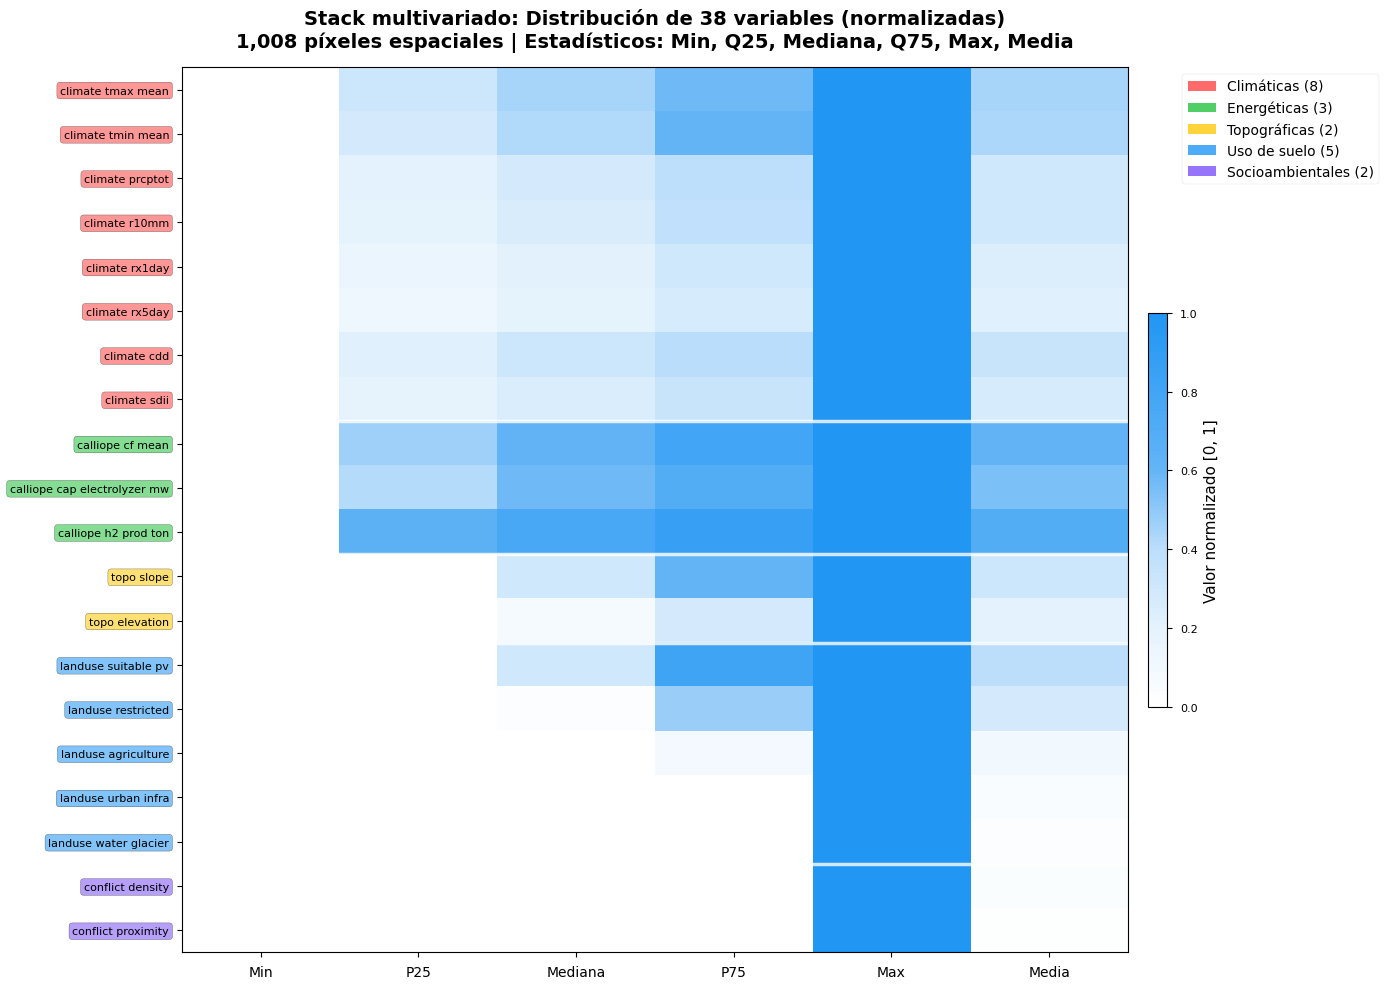

In [78]:
# Crear heatmap tipo "layer cake" con normalización por variable
fig, ax = plt.subplots(figsize=(14, max(10, len(all_vars) * 0.3)))

# Extraer datos y normalizar cada variable a [0, 1]
data_matrix = []
var_names_display = []
for var in all_vars:
    if var in ds.data_vars:
        vals = ds[var].values.flatten()
        vals = vals[~np.isnan(vals)]  # Remover NaNs
        if len(vals) > 0:
            # Normalizar a [0, 1] para que todas las variables sean comparables
            vmin, vmax = vals.min(), vals.max()
            if vmax > vmin:  # Evitar división por cero
                vals_norm = (vals - vmin) / (vmax - vmin)
            else:
                vals_norm = np.zeros_like(vals)
            
            data_matrix.append([
                vals_norm.min(), 
                np.percentile(vals_norm, 25), 
                np.median(vals_norm), 
                np.percentile(vals_norm, 75), 
                vals_norm.max(), 
                vals_norm.mean()
            ])
            var_names_display.append(var.replace('_', ' '))
        else:
            data_matrix.append([0, 0, 0, 0, 0, 0])
            var_names_display.append(var.replace('_', ' '))

data_matrix = np.array(data_matrix)

# Crear colormap personalizado: blanco -> celeste (azul suave)
from matplotlib.colors import LinearSegmentedColormap
colors = ['#FFFFFF', '#E3F2FD', '#BBDEFB', '#64B5F6', '#42A5F5', '#2196F3']
n_bins = 100
cmap_custom = LinearSegmentedColormap.from_list('white_blue', colors, N=n_bins)

# Plot heatmap
im = ax.imshow(data_matrix, aspect='auto', cmap=cmap_custom, interpolation='nearest', vmin=0, vmax=1)

# Configurar ejes
ax.set_yticks(range(len(var_names_display)))
ax.set_yticklabels(var_names_display, fontsize=8)
ax.set_xticks(range(6))
ax.set_xticklabels(['Min', 'P25', 'Mediana', 'P75', 'Max', 'Media'], fontsize=10)

# Colorear categorías en el eje Y con los colores pasteles definidos
for i, cat in enumerate(category_labels):
    if i < len(ax.get_yticklabels()):
        ax.get_yticklabels()[i].set_bbox(dict(boxstyle='round,pad=0.3', 
                                              facecolor=category_colors.get(cat, '#DDDDDD'), alpha=0.7))

# Líneas separadoras entre categorías
prev_cat = None
for i, cat in enumerate(category_labels):
    if prev_cat and cat != prev_cat:
        ax.axhline(i - 0.5, color='white', linewidth=2.5, linestyle='-', alpha=0.8)
    prev_cat = cat

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Valor normalizado [0, 1]', fontsize=11)

ax.set_title('Stack multivariado: Distribución de 38 variables (normalizadas)\n' +
             '1,008 píxeles espaciales | Estadísticos: Min, Q25, Mediana, Q75, Max, Media', 
             fontsize=14, fontweight='bold', pad=15)

# Leyenda de categorías
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=category_colors[cat], label=f"{cat} ({category_labels.count(cat)})") 
                   for cat in category_colors.keys() if cat in category_labels]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=10)

plt.tight_layout()

# Guardar archivos
output_png = PLOTS_DIR / 'img-heatmap-variables.png'
output_pdf = PLOTS_DIR / 'img-heatmap-variables.pdf'

plt.savefig(output_png, dpi=300, bbox_inches='tight')
plt.savefig(output_pdf, bbox_inches='tight')
print(f"\nArchivos guardados:")
print(f"  PNG: {output_png}")
print(f"  PDF: {output_pdf}")
print(f"\nCaption LaTeX:")
print(r"\caption{Heatmap de distribución de 38 variables normalizadas del stack multivariado. Se muestran estadísticos descriptivos (mínimo, percentil 25, mediana, percentil 75, máximo y media) para 1,008 píxeles espaciales. Las variables están agrupadas por categorías: Climáticas, Energéticas, Topográficas, Uso de suelo y Socioambientales.}")
plt.show()

## 4. Comparación bias correction (CMIP6 vs CR2MET)

Ejemplo con tasmax para mostrar el efecto de la corrección de sesgo

In [79]:
# Cargar datos de ejemplo (si existen)
cr2met_path = DATA_DIR / 'cr2met' / 'clima.zarr'
cmip6_raw_path = DATA_DIR / 'cmip6' / 'ACCESS-CM2' / 'tasmax' / 'historical'
cmip6_corrected_path = DATA_DIR / 'cmip6' / 'out' / 'corrected' / 'ACCESS-CM2' / 'tasmax' / 'historical'

# Placeholder - ajustar según estructura real de datos
print("Para generar este gráfico necesitamos:")
print(f"1. CR2MET: {cr2met_path}")
print(f"2. CMIP6 raw: {cmip6_raw_path}")
print(f"3. CMIP6 corregido: {cmip6_corrected_path}")
print("\nEste gráfico mostrará histogramas/mapas comparativos de tasmax")

Para generar este gráfico necesitamos:
1. CR2MET: /home/aninotna/magister/tesis/justh2_pipeline/data/cr2met/clima.zarr
2. CMIP6 raw: /home/aninotna/magister/tesis/justh2_pipeline/data/cmip6/ACCESS-CM2/tasmax/historical
3. CMIP6 corregido: /home/aninotna/magister/tesis/justh2_pipeline/data/cmip6/out/corrected/ACCESS-CM2/tasmax/historical

Este gráfico mostrará histogramas/mapas comparativos de tasmax


## 5. Distribuciones por tipo de variable


Archivos guardados:
  PNG: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-plot-distribuciones-categorias.png
  PDF: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-plot-distribuciones-categorias.pdf

Caption LaTeX:
\caption{Distribuciones de frecuencia por categoría de variable. Se muestra la variabilidad de valores para las cinco categorías principales: Climáticas, Energéticas, Topográficas, Uso de suelo y Socioambientales. Cada histograma representa una muestra de hasta 5 variables por categoría sobre 1,000 píxeles.}


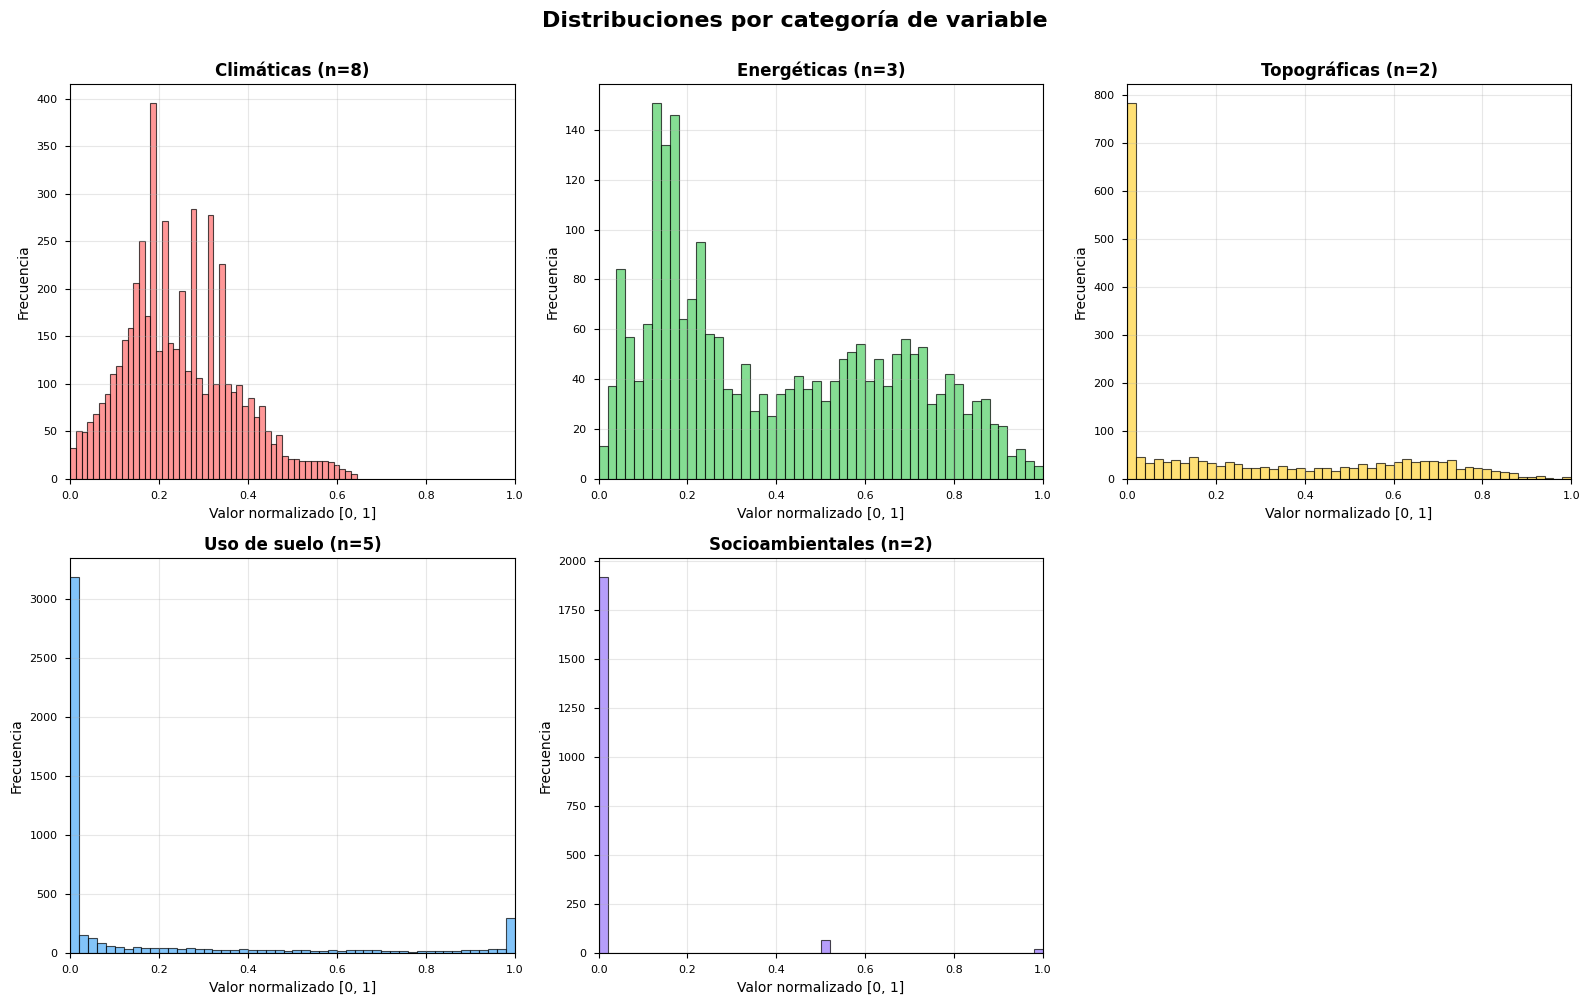

In [80]:
# Crear panel de distribuciones
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (cat, vars_list) in enumerate(var_categories.items()):
    if idx >= 6 or not vars_list:
        continue
    
    ax = axes[idx]
    
    # Combinar datos de todas las variables de esta categoría NORMALIZADAS
    cat_data = []
    for var in vars_list[:5]:  # Limitar a 5 variables por categoría para claridad
        if var in ds.data_vars:
            vals = ds[var].values.flatten()
            vals = vals[~np.isnan(vals)]
            
            # Normalizar cada variable a [0, 1] para que sean comparables
            if len(vals) > 0:
                vmin, vmax = vals.min(), vals.max()
                if vmax > vmin:
                    vals_norm = (vals - vmin) / (vmax - vmin)
                    cat_data.extend(vals_norm[:1000])  # Samplear para velocidad
    
    if cat_data:
        ax.hist(cat_data, bins=50, alpha=0.7, 
                color=category_colors.get(cat, '#DDDDDD'), 
                edgecolor='black', linewidth=0.8)
        ax.set_title(f"{cat} (n={len(vars_list)})", fontsize=12, fontweight='bold')
        ax.set_xlabel('Valor normalizado [0, 1]', fontsize=10)
        ax.set_ylabel('Frecuencia', fontsize=10)
        ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f"{cat}", fontsize=12)

# Ocultar ejes sobrantes
for idx in range(len(var_categories), 6):
    axes[idx].axis('off')

plt.suptitle('Distribuciones por categoría de variable', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

# Guardar archivos
output_png = PLOTS_DIR / 'img-plot-distribuciones-categorias.png'
output_pdf = PLOTS_DIR / 'img-plot-distribuciones-categorias.pdf'

plt.savefig(output_png, dpi=300, bbox_inches='tight')
plt.savefig(output_pdf, bbox_inches='tight')
print(f"\nArchivos guardados:")
print(f"  PNG: {output_png}")
print(f"  PDF: {output_pdf}")
print(f"\nCaption LaTeX:")
print(r"\caption{Distribuciones de frecuencia por categoría de variable. Se muestra la variabilidad de valores para las cinco categorías principales: Climáticas, Energéticas, Topográficas, Uso de suelo y Socioambientales. Cada histograma representa una muestra de hasta 5 variables por categoría sobre 1,000 píxeles.}")
plt.show()

## 6. Mapas espaciales por categoría de variable

Variables disponibles en el dataset:
['calliope_cf_mean', 'calliope_cap_electrolyzer_mw', 'calliope_h2_prod_ton', 'climate_tmax_mean', 'climate_tmin_mean', 'climate_prcptot', 'climate_r10mm', 'climate_rx1day', 'climate_rx5day', 'climate_cdd', 'climate_sdii', 'topo_slope', 'topo_elevation', 'landuse_suitable_pv', 'landuse_restricted', 'landuse_agriculture', 'landuse_urban_infra', 'landuse_water_glacier', 'conflict_density', 'conflict_proximity']

Total: 20 variables

Variables seleccionadas por categoría:
  Climáticas: ['climate_tmax_mean', 'climate_tmin_mean', 'climate_prcptot']
  Energéticas: ['calliope_cf_mean', 'calliope_cap_electrolyzer_mw', 'calliope_h2_prod_ton']
  Topográficas: ['topo_slope', 'topo_elevation']
  Uso de suelo: ['landuse_suitable_pv', 'landuse_restricted', 'landuse_agriculture']
  Socioambientales: ['conflict_density', 'conflict_proximity']
  climate_tmax_mean: shape (86, 24, 42) -> calculando media sobre primera dimensión (ignorando NaN)
  climate_tmin_mean: shap

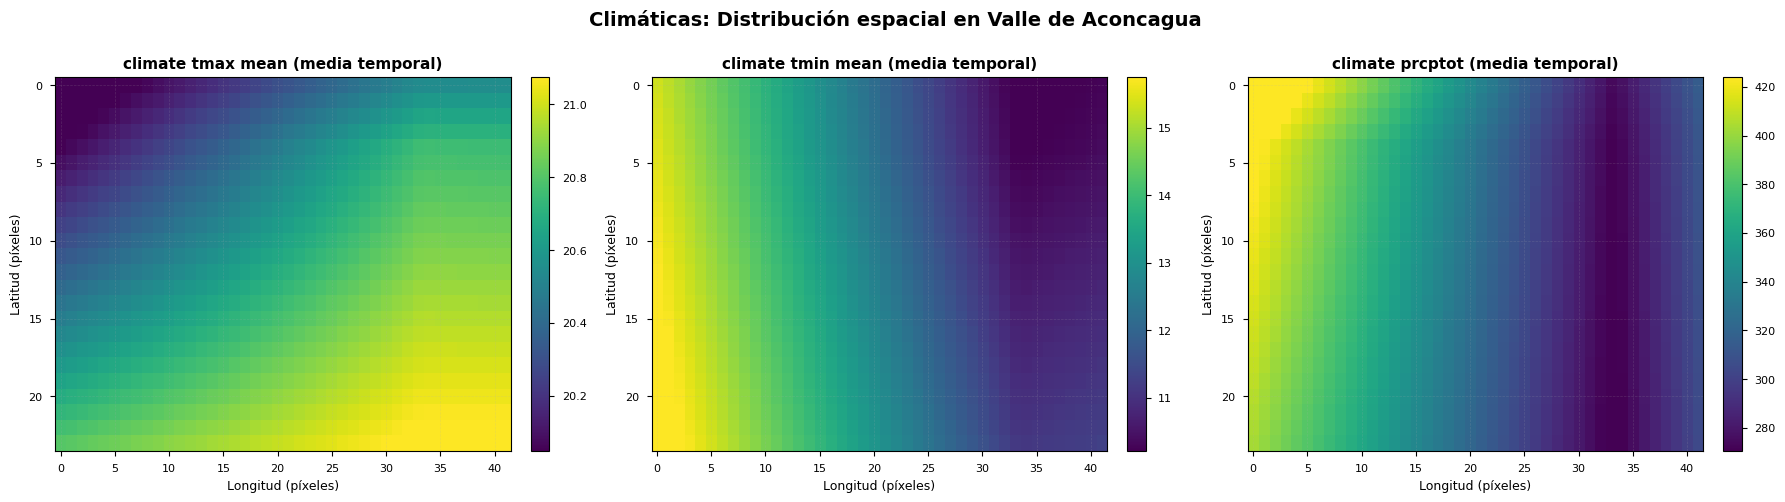

  calliope_h2_prod_ton: shape (86, 24, 42) -> calculando media sobre primera dimensión (ignorando NaN)


/tmp/ipykernel_705000/2904473067.py:49: RuntimeWarning: Mean of empty slice
  data = np.nanmean(data, axis=0)



Categoría: Energéticas
  Variables: calliope_cf_mean, calliope_cap_electrolyzer_mw, calliope_h2_prod_ton
  PNG: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-energeticas.png
  PDF: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-energeticas.pdf

Caption LaTeX:
\caption{Distribución espacial de variables energéticas en el Valle de Aconcagua. Se muestran 3 variables representativas sobre la grilla de 24×42 píxeles (~5 km de resolución). Colormap viridis para mayor contraste.}


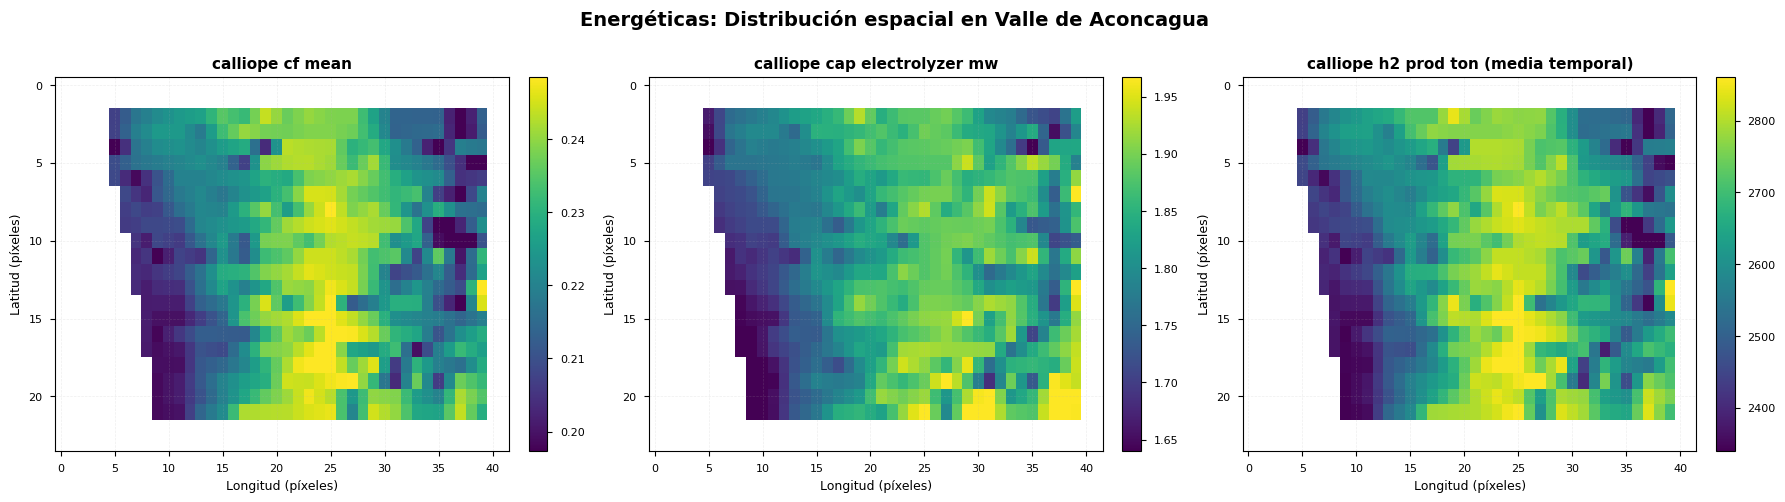


Categoría: Topográficas
  Variables: topo_slope, topo_elevation
  PNG: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-topograficas.png
  PDF: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-topograficas.pdf

Caption LaTeX:
\caption{Distribución espacial de variables topográficas en el Valle de Aconcagua. Se muestran 2 variables representativas sobre la grilla de 24×42 píxeles (~5 km de resolución). Colormap viridis para mayor contraste.}


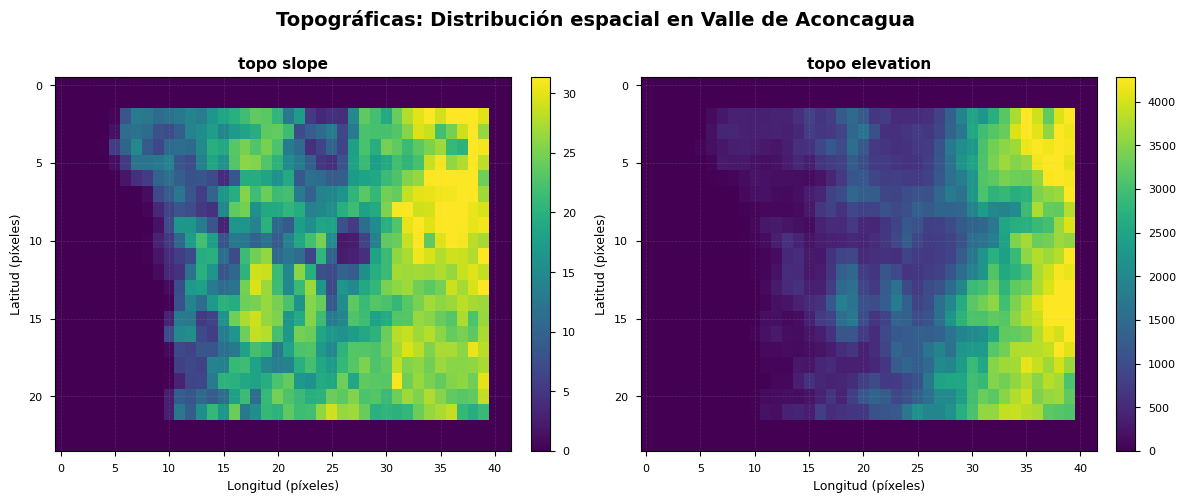


Categoría: Uso de suelo
  Variables: landuse_suitable_pv, landuse_restricted, landuse_agriculture
  PNG: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-uso-de-suelo.png
  PDF: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-uso-de-suelo.pdf

Caption LaTeX:
\caption{Distribución espacial de variables uso de suelo en el Valle de Aconcagua. Se muestran 3 variables representativas sobre la grilla de 24×42 píxeles (~5 km de resolución). Colormap viridis para mayor contraste.}


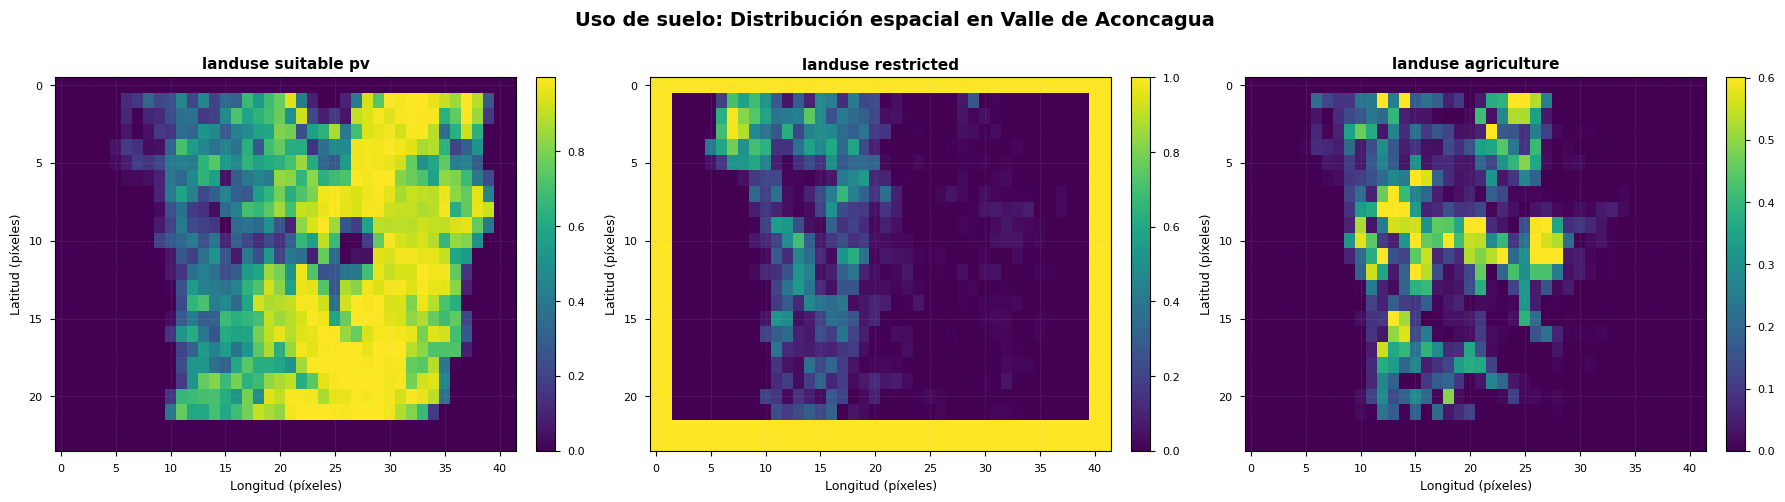


Categoría: Socioambientales
  Variables: conflict_density, conflict_proximity
  PNG: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-socioambientales.png
  PDF: /home/aninotna/magister/tesis/justh2_pipeline/plots/tesis_data_section/img-map-variables-socioambientales.pdf

Caption LaTeX:
\caption{Distribución espacial de variables socioambientales en el Valle de Aconcagua. Se muestran 2 variables representativas sobre la grilla de 24×42 píxeles (~5 km de resolución). Colormap viridis para mayor contraste.}


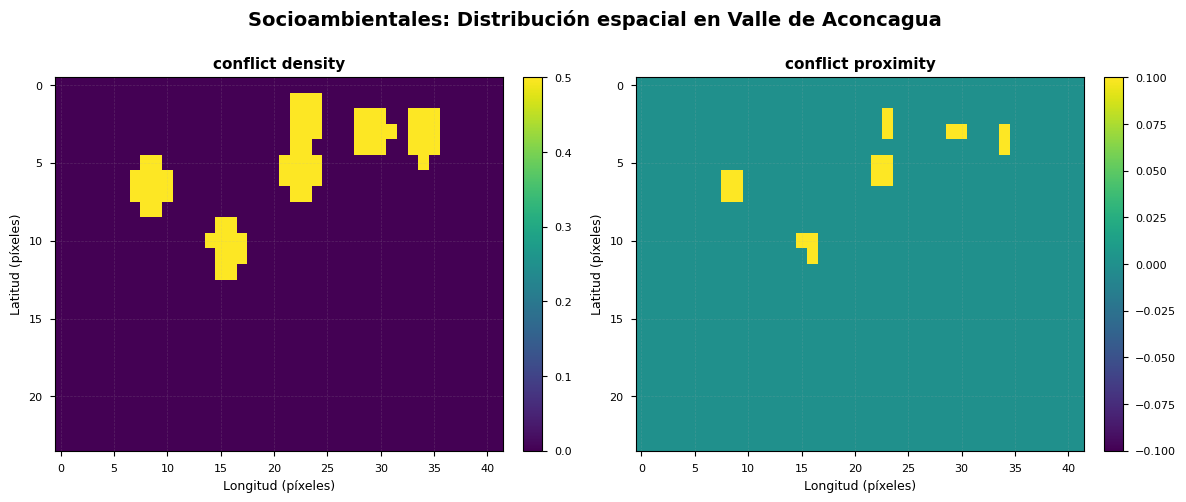

In [87]:
# Seleccionar variables representativas de cada categoría para visualización espacial
# Primero, listar todas las variables disponibles
print("Variables disponibles en el dataset:")
print(list(ds.data_vars))
print(f"\nTotal: {len(ds.data_vars)} variables")

# Usar las categorías ya definidas que sabemos que funcionan
representative_vars = {}
for cat, vars_list in var_categories.items():
    if vars_list:
        # Tomar hasta 3 variables representativas de cada categoría
        representative_vars[cat] = vars_list[:3]

print(f"\nVariables seleccionadas por categoría:")
for cat, vars_list in representative_vars.items():
    print(f"  {cat}: {vars_list}")

# Crear mapas espaciales para cada categoría
for cat, vars_list in representative_vars.items():
    # Filtrar variables que existen en el dataset (ya están filtradas)
    existing_vars = vars_list
    if not existing_vars:
        print(f"Categoría {cat}: No hay variables disponibles")
        continue
    
    n_vars = len(existing_vars)
    ncols = min(3, n_vars)
    nrows = int(np.ceil(n_vars / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    
    # Asegurar que axes sea siempre iterable
    if n_vars == 1:
        axes = [axes]
    elif nrows == 1:
        axes = axes if ncols > 1 else [axes]
    else:
        axes = axes.flatten()
    
    for i, var in enumerate(existing_vars):
        ax = axes[i]
        
        # Extraer datos y manejar dimensiones
        data = ds[var].values
        
        # Si tiene más de 2 dimensiones (ej: tiempo, lat, lon), calcular media temporal
        if data.ndim > 2:
            print(f"  {var}: shape {data.shape} -> calculando media sobre primera dimensión (ignorando NaN)")
            data = np.nanmean(data, axis=0)
        
        # Normalizar datos para mejor visualización si la varianza es muy baja
        data_min, data_max = np.nanmin(data), np.nanmax(data)
        data_range = data_max - data_min
        
        if data_range < 1e-10:  # Valores casi constantes
            print(f"    WARNING: {var} tiene rango muy pequeño ({data_range:.2e}), usando valores absolutos")
            vmin_plot, vmax_plot = data_min - 0.01, data_max + 0.01
        else:
            # Usar percentiles para mejorar contraste
            vmin_plot = np.nanpercentile(data, 2)
            vmax_plot = np.nanpercentile(data, 98)
        
        # Crear mapa con mejor contraste
        im = ax.imshow(data, cmap='viridis', aspect='auto', interpolation='nearest',
                      vmin=vmin_plot, vmax=vmax_plot)
        
        # Configurar colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        
        # Título y etiquetas
        title_suffix = ' (media temporal)' if ds[var].values.ndim > 2 else ''
        ax.set_title(var.replace('_', ' ') + title_suffix, fontsize=11, fontweight='bold')
        ax.set_xlabel('Longitud (píxeles)', fontsize=9)
        ax.set_ylabel('Latitud (píxeles)', fontsize=9)
        
        # Agregar grid sutil
        ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Ocultar subplots sobrantes
    for j in range(n_vars, len(axes)):
        axes[j].axis('off')
    
    # Título general
    plt.suptitle(f'{cat}: Distribución espacial en Valle de Aconcagua', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    # Guardar archivos
    cat_slug = cat.lower().replace(' ', '-').replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
    output_png = PLOTS_DIR / f'img-map-variables-{cat_slug}.png'
    output_pdf = PLOTS_DIR / f'img-map-variables-{cat_slug}.pdf'
    
    plt.savefig(output_png, dpi=300, bbox_inches='tight')
    plt.savefig(output_pdf, bbox_inches='tight')
    
    print(f"\nCategoría: {cat}")
    print(f"  Variables: {', '.join(existing_vars)}")
    print(f"  PNG: {output_png}")
    print(f"  PDF: {output_pdf}")
    print(f"\nCaption LaTeX:")
    print(f"\\caption{{Distribución espacial de variables {cat.lower()} en el Valle de Aconcagua. Se muestran {n_vars} variables representativas sobre la grilla de 24×42 píxeles (~5 km de resolución). Colormap viridis para mayor contraste.}}")
    
    plt.show()

## 7. Resumen de archivos generados

In [71]:
print("\nArchivos generados para la tesis:")
for f in sorted(PLOTS_DIR.glob('*')):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:50s} ({size_mb:.2f} MB)")
print(f"\nDirectorio: {PLOTS_DIR}")


Archivos generados para la tesis:
  img-heatmap-variables.pdf                          (0.04 MB)
  img-heatmap-variables.png                          (0.34 MB)
  img-map-grilla-valle-aconcagua.pdf                 (0.74 MB)
  img-map-grilla-valle-aconcagua.png                 (3.46 MB)
  img-map-variables-climaticas.pdf                   (0.04 MB)
  img-map-variables-climaticas.png                   (0.28 MB)
  img-map-variables-energeticas.pdf                  (0.04 MB)
  img-map-variables-energeticas.png                  (0.26 MB)
  img-map-variables-socioambientales.pdf             (0.03 MB)
  img-map-variables-socioambientales.png             (0.14 MB)
  img-map-variables-topograficas.pdf                 (0.03 MB)
  img-map-variables-topograficas.png                 (0.19 MB)
  img-map-variables-uso-de-suelo.pdf                 (0.03 MB)
  img-map-variables-uso-de-suelo.png                 (0.23 MB)
  img-plot-distribuciones-categorias.pdf             (0.03 MB)
  img-plot-distribuc